## Does it correlate?

In [22]:
import geopandas as gpd
import esda
import matplotlib.pyplot as plt
import seaborn as sns

from libpysal import graph

Read it as a GeoDataFrame and assign a column you think would be the best as an index.

In [23]:
simd = gpd.read_file("https://maps.gov.scot/ATOM/shapefiles/SG_SIMD_2020.zip")
simd = simd.set_index("DataZone")

Filter the data to work only with Glasgow.

If you check the Excel file in the zip above, you will learn that a column LAName represents Local Authority name. You can use it to filter Glasgow.

Since the string may be something else than “Glasgow”, let’s find out the right one. You can list all unique names in the LAName column.

In [24]:
simd.LAName.unique()

array(['Aberdeen City', 'Aberdeenshire', 'Angus', 'Argyll and Bute',
       'Clackmannanshire', 'Dumfries and Galloway', 'Dundee City',
       'East Ayrshire', 'East Dunbartonshire', 'East Lothian',
       'East Renfrewshire', 'City of Edinburgh', 'Na h-Eileanan an Iar',
       'Falkirk', 'Fife', 'Glasgow City', 'Highland', 'Inverclyde',
       'Midlothian', 'Moray', 'North Ayrshire', 'North Lanarkshire',
       'Orkney Islands', 'Perth and Kinross', 'Renfrewshire',
       'Scottish Borders', 'Shetland Islands', 'South Ayrshire',
       'South Lanarkshire', 'Stirling', 'West Dunbartonshire',
       'West Lothian'], dtype=object)

From that you can see that the right string is ‘Glasgow City’. You can use that directly. But if you’d like to know the programmatic way (you can ask chatGPT to explain the code if you need):

In [25]:
glasgow_name = simd.LAName[simd.LAName.str.contains('Glasgow')].unique()[0]
glasgow_name

'Glasgow City'

In [26]:
glasgow = simd[simd.LAName == "Glasgow City"]

Create contiguity weights based on the reduced dataset.

In [27]:
contiguity = graph.Graph.build_contiguity(glasgow)

Create a binary variable from "Rankv2" encoding areas with rank above city-wide mean.

In [28]:
mean_rank = glasgow["Rankv2"].mean()
glasgow["better_half"] = glasgow["Rankv2"] > mean_rank

C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Measure Join Counts statistic on your new variable.

In [29]:
jc = esda.Join_Counts(
    glasgow["better_half"],
    contiguity,
)

Let’s print the results i a nice way. Using a multi-line f-string (google!):

In [30]:
print(f"""BB: {jc.bb}
WW: {jc.ww}
BW: {jc.bw}
J: {jc.J}
mean BB: {jc.mean_bb}
mean BW: {jc.mean_bw}
p_sim BB: {jc.p_sim_bb}
""")

BB: 567.0
WW: 943.0
BW: 553.0
J: 2063.0
mean BB: 344.46946946946946
mean BW: 998.3903903903904
p_sim BB: 0.001



Visualise the main "Rankv2" with a Moran Plot

In [31]:
glasgow['rank_std'] = (
    glasgow["Rankv2"] - glasgow["Rankv2"].mean()
) / glasgow["Rankv2"].std()

C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [32]:
contiguity_r = contiguity.transform("r")

glasgow['rank_lag'] = contiguity_r.lag(glasgow['rank_std'])

C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


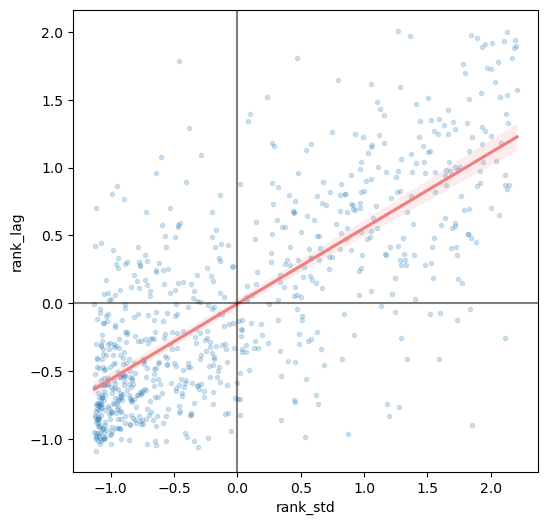

In [45]:
f, ax = plt.subplots(figsize=(6, 6))
sns.regplot(
    x="rank_std",
    y="rank_lag",
    data=glasgow,
    marker=".",
    scatter_kws={"alpha": 0.2},
    line_kws=dict(color="lightcoral")
)
ax.axvline(0, c="black", alpha=0.5)
ax.axhline(0, c="black", alpha=0.5)

Calculate Moran’s I 

In [34]:
mi = esda.Moran(glasgow['rank_std'], contiguity_r)

In [35]:
mi.I

0.5565153557531056

In [36]:
mi.p_sim

0.001

Calculate LISA statistics for the areas

In [37]:
lisa = esda.Moran_Local(glasgow['rank_std'], contiguity_r)

Make a map of significant clusters at the 5%

In [ ]:
lisa.explore(glasgow)

Create cluster maps for significance levels 1%

In [ ]:
lisa.explore(glasgow, crit_value=.01)

Create cluster maps for significance levels 10%;

lisa.explore(glasgow, crit_value=.1)

Create a single map that combines all three significance levels and changes the alpha to distinguish them.
Can you create both interactive and static versions of those maps?

In [40]:
m = lisa.explore(glasgow, crit_value=.1, tiles="CartoDB Positron")
lisa.explore(glasgow, m=m)
lisa.explore(glasgow, crit_value=.01, m=m)

But that probably won’t cut it in most cases. So it is time for a composed multi-layer plot.

C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\annak\OneDrive\Dokumenty\Skola\2.LS\sds\sds-Kryndlea\.pixi\envs\default\Lib\site-pack

<Axes: >

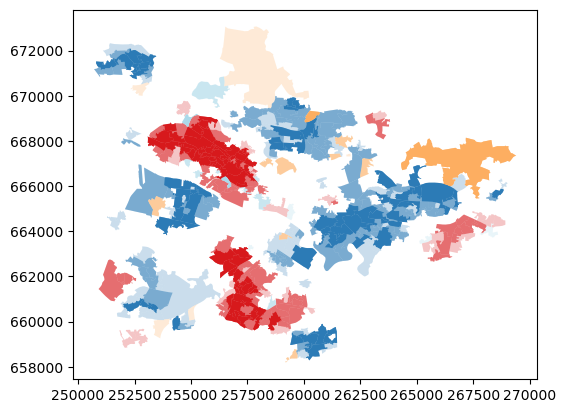

In [41]:
glasgow["labels_001"] = lisa.get_cluster_labels(0.01)
glasgow["labels_005"] = lisa.get_cluster_labels()
glasgow["labels_01"] = lisa.get_cluster_labels(0.1)


ax = glasgow.loc[(glasgow["labels_01"] == "High-High")].plot(color="#d7191c", alpha=.25)
glasgow.loc[(glasgow["labels_01"] == "Low-Low")].plot(ax=ax, color="#2c7bb6", alpha=.25)
glasgow.loc[(glasgow["labels_01"] == "Low-High")].plot(ax=ax, color="#abd9e9", alpha=.25)
glasgow.loc[(glasgow["labels_01"] == "High-Low")].plot(ax=ax, color="#fdae61", alpha=.25)

glasgow.loc[(glasgow["labels_005"] == "High-High")].plot(ax=ax, color="#d7191c", alpha=.5)
glasgow.loc[(glasgow["labels_005"] == "Low-Low")].plot(ax=ax, color="#2c7bb6", alpha=.5)
glasgow.loc[(glasgow["labels_005"] == "Low-High")].plot(ax=ax, color="#abd9e9", alpha=.5)
glasgow.loc[(glasgow["labels_005"] == "High-Low")].plot(ax=ax, color="#fdae61", alpha=.5)

glasgow.loc[(glasgow["labels_001"] == "High-High")].plot(ax=ax, color="#d7191c", alpha=1)
glasgow.loc[(glasgow["labels_001"] == "Low-Low")].plot(ax=ax, color="#2c7bb6", alpha=1)
glasgow.loc[(glasgow["labels_001"] == "Low-High")].plot(ax=ax, color="#abd9e9", alpha=1)
glasgow.loc[(glasgow["labels_001"] == "High-Low")].plot(ax=ax, color="#fdae61", alpha=1)